In [1]:
# ============================================================
# KIARA v2 - Cell 1
# Import required libraries and configure the environment.
# This cell loads all packages needed for preprocessing,
# deep learning, visualization, and evaluation.
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# ------------------------------------------------------------
# Suppress unnecessary warnings for cleaner notebook output.
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Set random seeds to make results reproducible.
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Enable TensorFlow optimizations (if supported).
# ------------------------------------------------------------

tf.keras.backend.clear_session()

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed Precision Policy:", tf.keras.mixed_precision.global_policy())

# ------------------------------------------------------------
# Display TensorFlow version.
# ------------------------------------------------------------
print("=" * 50)
print("KIARA v2 - Diabetic Retinopathy Detection")
print("=" * 50)
print("TensorFlow Version :", tf.__version__)
print("Num GPUs Available :", len(tf.config.list_physical_devices('GPU')))
print("=" * 50)

Mixed Precision Policy: <DTypePolicy "mixed_float16">
KIARA v2 - Diabetic Retinopathy Detection
TensorFlow Version : 2.20.0
Num GPUs Available : 2


In [2]:
import os

print("Contents of /kaggle/input:")
print("-" * 40)

for item in os.listdir("/kaggle/input"):
    print(item)

Contents of /kaggle/input:
----------------------------------------
competitions


In [3]:
import os

for folder in os.listdir("/kaggle/input"):
    print(f"\n📁 {folder}")
    path = os.path.join("/kaggle/input", folder)
    try:
        print(os.listdir(path)[:20])
    except Exception as e:
        print(e)


📁 competitions
['aptos2019-blindness-detection']


In [4]:
# ============================================================
# KIARA v2 - Cell 2
# Load the APTOS 2019 competition dataset.
# This cell creates image paths and checks dataset integrity.
# ============================================================

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------
DATASET_PATH = "/kaggle/input/competitions/aptos2019-blindness-detection"

TRAIN_CSV = os.path.join(DATASET_PATH, "train.csv")
TRAIN_IMAGES = os.path.join(DATASET_PATH, "train_images")

# ------------------------------------------------------------
# Load training CSV
# ------------------------------------------------------------
train_df = pd.read_csv(TRAIN_CSV)

# ------------------------------------------------------------
# Create full image paths
# ------------------------------------------------------------
train_df["filepath"] = train_df["id_code"].apply(
    lambda x: os.path.join(TRAIN_IMAGES, x + ".png")
)

# ------------------------------------------------------------
# Show dataset information
# ------------------------------------------------------------
print("=" * 50)
print("Dataset Loaded Successfully")
print("=" * 50)
print(f"Total Images : {len(train_df)}")
print(f"Classes      : {train_df['diagnosis'].nunique()}")

print("\nClass Distribution")
print(train_df["diagnosis"].value_counts().sort_index())

# ------------------------------------------------------------
# Check for missing images
# ------------------------------------------------------------
missing = (~train_df["filepath"].apply(os.path.exists)).sum()

print(f"\nMissing Images : {missing}")

# ------------------------------------------------------------
# Display first five records
# ------------------------------------------------------------
train_df.head()

Dataset Loaded Successfully
Total Images : 3662
Classes      : 5

Class Distribution
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Missing Images : 0


,id_code,diagnosis,filepath
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...


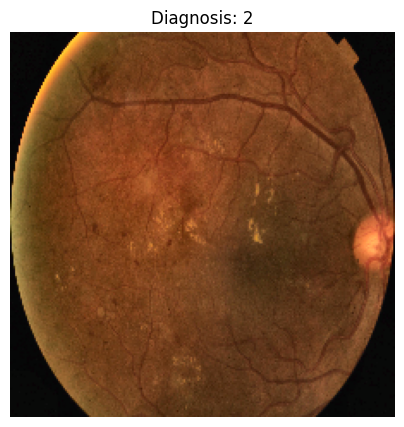

In [5]:
# ============================================================
# KIARA v2 - Cell 3
# Preprocess retinal fundus images before training.
# This cell removes black borders, enhances contrast,
# resizes images, and normalizes pixel values.
# ============================================================

# ------------------------------------------------------------
# Image size used throughout the project
# ------------------------------------------------------------
IMAGE_SIZE = 224

# ------------------------------------------------------------
# Crop black borders around the retina
# ------------------------------------------------------------
def crop_black(img, tol=7):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol

    if mask.any():
        img = img[np.ix_(mask.any(1), mask.any(0))]

    return img

# ------------------------------------------------------------
# Apply CLAHE to improve retinal vessel visibility
# ------------------------------------------------------------
def apply_clahe(img):

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))

    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

# ------------------------------------------------------------
# Complete preprocessing pipeline
# ------------------------------------------------------------
def preprocess_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = crop_black(img)

    img = apply_clahe(img)

    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

    img = img.astype(np.float32) / 255.0

    return img

# ------------------------------------------------------------
# Display one processed sample image
# ------------------------------------------------------------
sample_image = preprocess_image(train_df.loc[0, "filepath"])

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.title(f"Diagnosis: {train_df.loc[0, 'diagnosis']}")
plt.axis("off")
plt.show()

In [6]:
# ============================================================
# KIARA v2 - Cell 4
# Split the dataset into training and validation sets.
# This cell also creates an optimized tf.data pipeline
# for faster and more efficient model training.
# ============================================================

# ------------------------------------------------------------
# Split dataset (80% train, 20% validation)
# ------------------------------------------------------------
train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["diagnosis"],
    random_state=SEED
)

print(f"Training Images   : {len(train_data)}")
print(f"Validation Images : {len(val_data)}")

# ------------------------------------------------------------
# Function to load and preprocess an image
# ------------------------------------------------------------
def load_image(path, label):

    image = tf.numpy_function(
        preprocess_image,
        [path],
        tf.float32
    )

    image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))

    return image, label

# ------------------------------------------------------------
# Training dataset
# ------------------------------------------------------------
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_data["filepath"].values,
        train_data["diagnosis"].values
    )
)

train_ds = (
    train_ds
    .shuffle(len(train_data), seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ------------------------------------------------------------
# Validation dataset
# ------------------------------------------------------------
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_data["filepath"].values,
        val_data["diagnosis"].values
    )
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("\n✅ tf.data pipeline created successfully.")

Training Images   : 2929
Validation Images : 733


I0000 00:00:1785144213.832468      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785144213.835292      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



✅ tf.data pipeline created successfully.


In [7]:
# ============================================================
# KIARA v2 - Cell 5
# Create data augmentation and class weights.
# This cell increases training diversity and compensates
# for class imbalance in the APTOS dataset.
# ============================================================

# ------------------------------------------------------------
# Compute class weights
# ------------------------------------------------------------
classes = np.unique(train_data["diagnosis"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["diagnosis"]
)

class_weights = {
    i: float(w)
    for i, w in zip(classes, weights)
}

print("Class Weights")
print(class_weights)

# ------------------------------------------------------------
# Data Augmentation
# ------------------------------------------------------------
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.15),

    layers.RandomBrightness(0.10),

], name="data_augmentation")

print("\n✅ Data augmentation ready.")

Class Weights
{np.int64(0): 0.4056786703601108, np.int64(1): 1.979054054054054, np.int64(2): 0.7331664580725907, np.int64(3): 3.803896103896104, np.int64(4): 2.4822033898305085}

✅ Data augmentation ready.


In [8]:
# ------------------------------------------------------------
# Custom loss: sparse labels + label smoothing.
# tf.keras.losses.SparseCategoricalCrossentropy has no built-in
# label_smoothing argument (only the dense CategoricalCrossentropy
# does), so labels are one-hot encoded inside the loss function itself
# to get label smoothing without changing the tf.data pipeline's
# integer-label output.
# ------------------------------------------------------------
def sparse_crossentropy_with_label_smoothing(y_true, y_pred, num_classes=5, label_smoothing=0.05):
    y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
    return tf.keras.losses.categorical_crossentropy(
        y_true_onehot, y_pred, label_smoothing=label_smoothing
    )

print("Custom label-smoothed loss function defined.")

Custom label-smoothed loss function defined.


In [9]:
# ============================================================
# KIARA v2 - Cell 6
# Build the ResNet50 transfer learning model.
# This cell loads ImageNet weights and creates
# the final classification network.
# ============================================================

# ------------------------------------------------------------
# Load pretrained ResNet50 backbone
# ------------------------------------------------------------
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

# ------------------------------------------------------------
# Freeze backbone during baseline training
# ------------------------------------------------------------
base_model.trainable = False

# ------------------------------------------------------------
# Build the KIARA model
# ------------------------------------------------------------
inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Data augmentation (training only)
x = data_augmentation(inputs)

# ResNet50 preprocessing
x = tf.keras.applications.resnet50.preprocess_input(x * 255.0)

# Feature extraction
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.50)(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

kiara_model = tf.keras.Model(
    inputs,
    outputs,
    name="KIARA_ResNet50"
)

# ------------------------------------------------------------
# Compile model
# ------------------------------------------------------------
kiara_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Display architecture
# ------------------------------------------------------------
kiara_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "KIARA_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ data_augmentatio… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │      2,565 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,649,605 (94.03 MB)

 Trainable params: 1,056,773 (4.03 MB)

 Non-trainable params: 23,592,832 (90.00 MB)

In [10]:
# ============================================================
# KIARA v2 - Cell 7 (NEW)
# Stage 1: Train the classifier head only (backbone frozen).
# ============================================================

warmup_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/kiara_resnet50_warmup.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

]

WARMUP_EPOCHS = 15

history_warmup = kiara_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=WARMUP_EPOCHS,

    class_weight=class_weights,

    callbacks=warmup_callbacks,

    verbose=1

)

print("\nStage 1 (head warm-up) complete.")
print(f"Best warm-up validation accuracy: {max(history_warmup.history['val_accuracy']):.4f}")


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1458 - loss: 2.6380
Epoch 1: val_accuracy improved from None to 0.43383, saving model to /kaggle/working/kiara_resnet50_warmup.keras

Epoch 1: finished saving model to /kaggle/working/kiara_resnet50_warmup.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 373s 4s/step - accuracy: 0.1635 - loss: 2.4508 - val_accuracy: 0.4338 - val_loss: 1.6078 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2100 - loss: 2.0643
Epoch 2: val_accuracy improved from 0.43383 to 0.53479, saving model to /kaggle/working/kiara_resnet50_warmup.keras

Epoch 2: finished saving model to /kaggle/working/kiara_resnet50_warmup.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.1984 - loss: 2.0946 - val_accuracy: 0.5348 - val_loss: 1.2279 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1966 - loss: 2.1293
Epoch 3: val_accuracy did not improve from 0.53479
92/92 ━━━━━━━━━━━━━━━━━━━━ 343s 4

KeyboardInterrupt: 

In [ ]:
# ============================================================
# KIARA v2 - Cell 8
# Stage 2: Fine-Tune ResNet50 (top ~100 layers unfrozen)
# ============================================================

# ------------------------------------------------------------
# Unfreeze the last 100 layers of ResNet50
# ------------------------------------------------------------

base_model.trainable = True

# Freeze all layers except the last 100
for layer in base_model.layers[:-100]:
    layer.trainable = False

print(f"Trainable backbone layers: {sum([l.trainable for l in base_model.layers])} "
      f"/ {len(base_model.layers)}")

# ------------------------------------------------------------
# Recompile with a small learning rate
# ------------------------------------------------------------

kiara_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),

    loss=sparse_crossentropy_with_label_smoothing,

    metrics=["accuracy"]

)

# ------------------------------------------------------------
# Fine-tuning callbacks
# ------------------------------------------------------------

finetune_callbacks_stage2 = [

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/kiara_resnet50_finetuned_stage2.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

]

STAGE2_EPOCHS = 20

# ------------------------------------------------------------
# Fine-tune the model
# ------------------------------------------------------------

history_stage2 = kiara_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=STAGE2_EPOCHS,

    class_weight=class_weights,

    callbacks=finetune_callbacks_stage2,

    verbose=1

)

print("\nStage 2 (partial fine-tune) complete.")
print(f"Best Stage 2 validation accuracy: {max(history_stage2.history['val_accuracy']):.4f}")


In [ ]:
# ============================================================
# KIARA v2 - Cell 9 (NEW)
# Stage 3: Full-backbone fine-tune at a very low learning rate.
# ============================================================

base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = True

print(f"Trainable backbone layers: {sum([l.trainable for l in base_model.layers])} "
      f"/ {len(base_model.layers)}")

kiara_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),

    loss=sparse_crossentropy_with_label_smoothing,

    metrics=["accuracy"]

)

finetune_callbacks_stage3 = [

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/kiara_resnet50_finetuned_stage3.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )

]

STAGE3_EPOCHS = 5

history_stage3 = kiara_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=STAGE3_EPOCHS,

    class_weight=class_weights,

    callbacks=finetune_callbacks_stage3,

    verbose=1

)

print("\nStage 3 (full fine-tune) complete.")
print(f"Best Stage 3 validation accuracy: {max(history_stage3.history['val_accuracy']):.4f}")


In [11]:
# ============================================================
# KIARA ResNet50 - Training Curves (Warm-up Only)
# ============================================================

train_acc = history_warmup.history["accuracy"]
val_acc = history_warmup.history["val_accuracy"]

train_loss = history_warmup.history["loss"]
val_loss = history_warmup.history["val_loss"]

epochs_range = range(1, len(train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -------------------------------
# Loss Curve
# -------------------------------
axes[0].plot(epochs_range, train_loss, label="Train Loss")
axes[0].plot(epochs_range, val_loss, label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("ResNet50 Loss Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -------------------------------
# Accuracy Curve
# -------------------------------
axes[1].plot(epochs_range, train_acc, label="Train Accuracy")
axes[1].plot(epochs_range, val_acc, label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("ResNet50 Accuracy Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("KIARA ResNet50 - Warm-up Training History", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {max(val_acc):.4f}")
print(f"Best Epoch: {val_acc.index(max(val_acc)) + 1}")

NameError: name 'history_warmup' is not defined

In [12]:
all_train_acc = (
    history_warmup.history["accuracy"]
    + history_stage3.history["accuracy"]
)

all_val_acc = (
    history_warmup.history["val_accuracy"]
    + history_stage3.history["val_accuracy"]
)

all_train_loss = (
    history_warmup.history["loss"]
    + history_stage3.history["loss"]
)

all_val_loss = (
    history_warmup.history["val_loss"]
    + history_stage3.history["val_loss"]
)

stage3_start = len(history_warmup.history["accuracy"]) + 0.5

epochs_range = range(1, len(all_train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].plot(epochs_range, all_train_loss, label="Train Loss")
axes[0].plot(epochs_range, all_val_loss, label="Val Loss")
axes[0].axvline(stage3_start, color="black", linestyle="--", label="Stage 3 starts")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, all_train_acc, label="Train Accuracy")
axes[1].plot(epochs_range, all_val_acc, label="Val Accuracy")
axes[1].axvline(stage3_start, color="black", linestyle="--", label="Stage 3 starts")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

print(f"Best validation accuracy: {max(all_val_acc):.4f}")

NameError: name 'history_warmup' is not defined

In [13]:
kiara_model = tf.keras.models.load_model(
    "/kaggle/working/kiara_resnet50_finetuned_stage3.keras",
    custom_objects={
        "sparse_crossentropy_with_label_smoothing": sparse_crossentropy_with_label_smoothing
    }
)

results = kiara_model.evaluate(test_ds)

print(results)

ValueError: File not found: filepath=/kaggle/working/kiara_resnet50_finetuned_stage3.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
# ============================================================
# Final Model Save (TensorFlow / Keras)
# ============================================================

FINAL_MODEL_PATH = "kiara_resnet50_final.keras"

# kiara_model already holds the best weights across all three stages,
# since every EarlyStopping callback used restore_best_weights=True.
kiara_model.save(FINAL_MODEL_PATH)

print(f"Final model saved to : {FINAL_MODEL_PATH}")
print(f"Best validation accuracy achieved: {max(all_val_acc):.4f}")


In [14]:
kiara_model.save("/kaggle/working/kiara_resnet50_best.keras")
print("Model saved successfully!")

Model saved successfully!
